**Logistic Regression on Breast Cancer Wisconsin (Diagnostic)**


*Task 1: Data Acquisition and Exploration *


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Outcome")

df = X.copy()
df["Outcome"] = y

print("Dataset shape:", df.shape)
print("\nTarget classes:")
print(dict(enumerate(data.target_names)))

display(df.head())


Dataset shape: (569, 31)

Target classes:
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
print("Summary statistics:")
display(df.describe().T)

print("\nMedian:")
display(df.median(numeric_only=True).to_frame("median"))

print("\nStandard deviation:")
display(df.std(numeric_only=True).to_frame("std"))


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



Median:


,median
mean radius,13.370000
mean texture,18.840000
mean perimeter,86.240000
mean area,551.100000
mean smoothness,0.095870
mean compactness,0.092630
mean concavity,0.061540
mean concave points,0.033500
mean symmetry,0.179200
mean fractal dimension,0.061540



Standard deviation:


,std
mean radius,3.524049
mean texture,4.301036
mean perimeter,24.298981
mean area,351.914129
mean smoothness,0.014064
mean compactness,0.052813
mean concavity,0.079720
mean concave points,0.038803
mean symmetry,0.027414
mean fractal dimension,0.007060


In [3]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

# IQR-based outlier counts for each numerical feature.
outlier_counts = {}

for col in X.columns:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = int(((X[col] < lower) | (X[col] > upper)).sum())

outlier_df = pd.Series(outlier_counts, name="outlier_count").sort_values(ascending=False)

print("\nTop features by IQR outlier count:")
display(outlier_df.head(10))

# The dataset contains no missing values and no duplicate rows.
# For model training, extreme values are retained because they may contain
# clinically relevant diagnostic information; standardization limits scale effects.


Missing values:
0

Duplicate rows:
0

Top features by IQR outlier count:


,outlier_count
area error,65
radius error,38
perimeter error,38
worst area,35
smoothness error,30
fractal dimension error,28
compactness error,28
symmetry error,27
mean area,25
worst fractal dimension,24


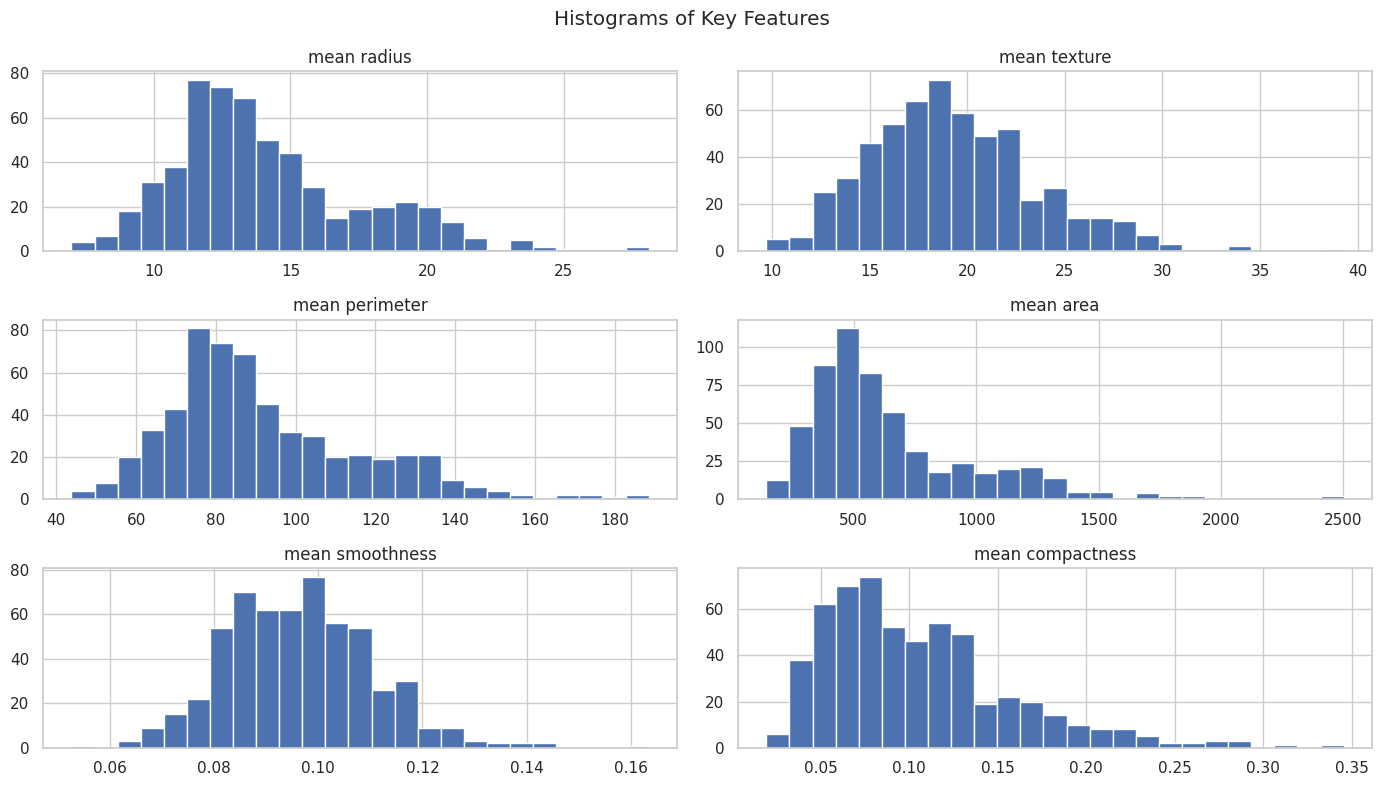

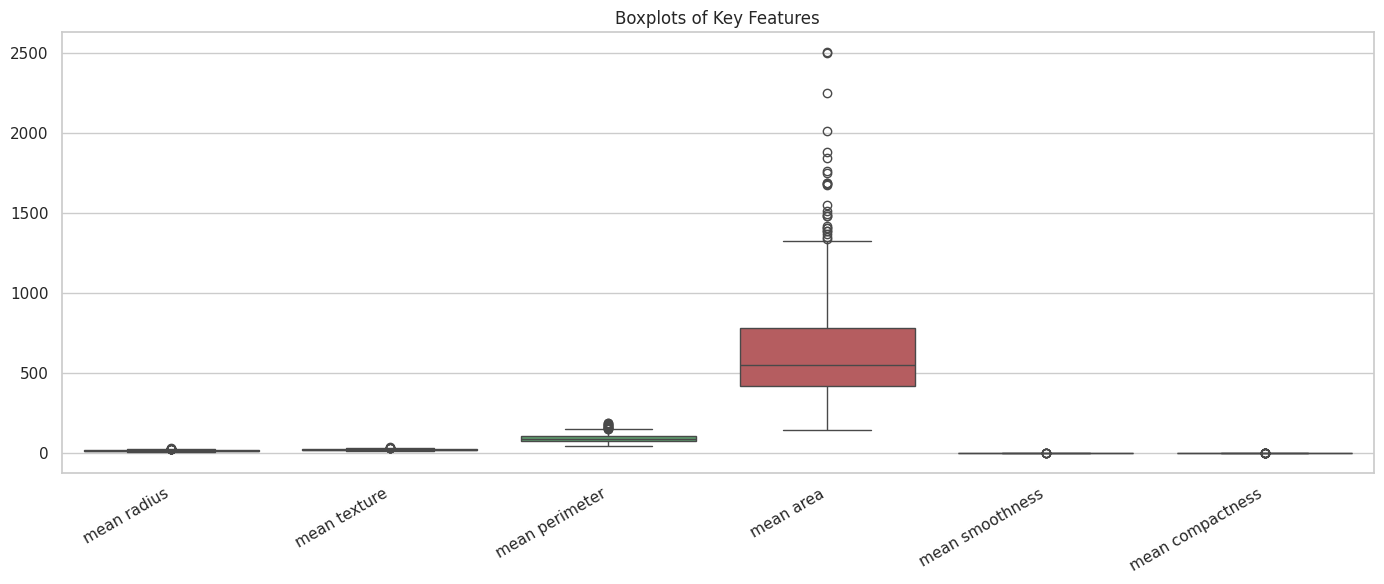

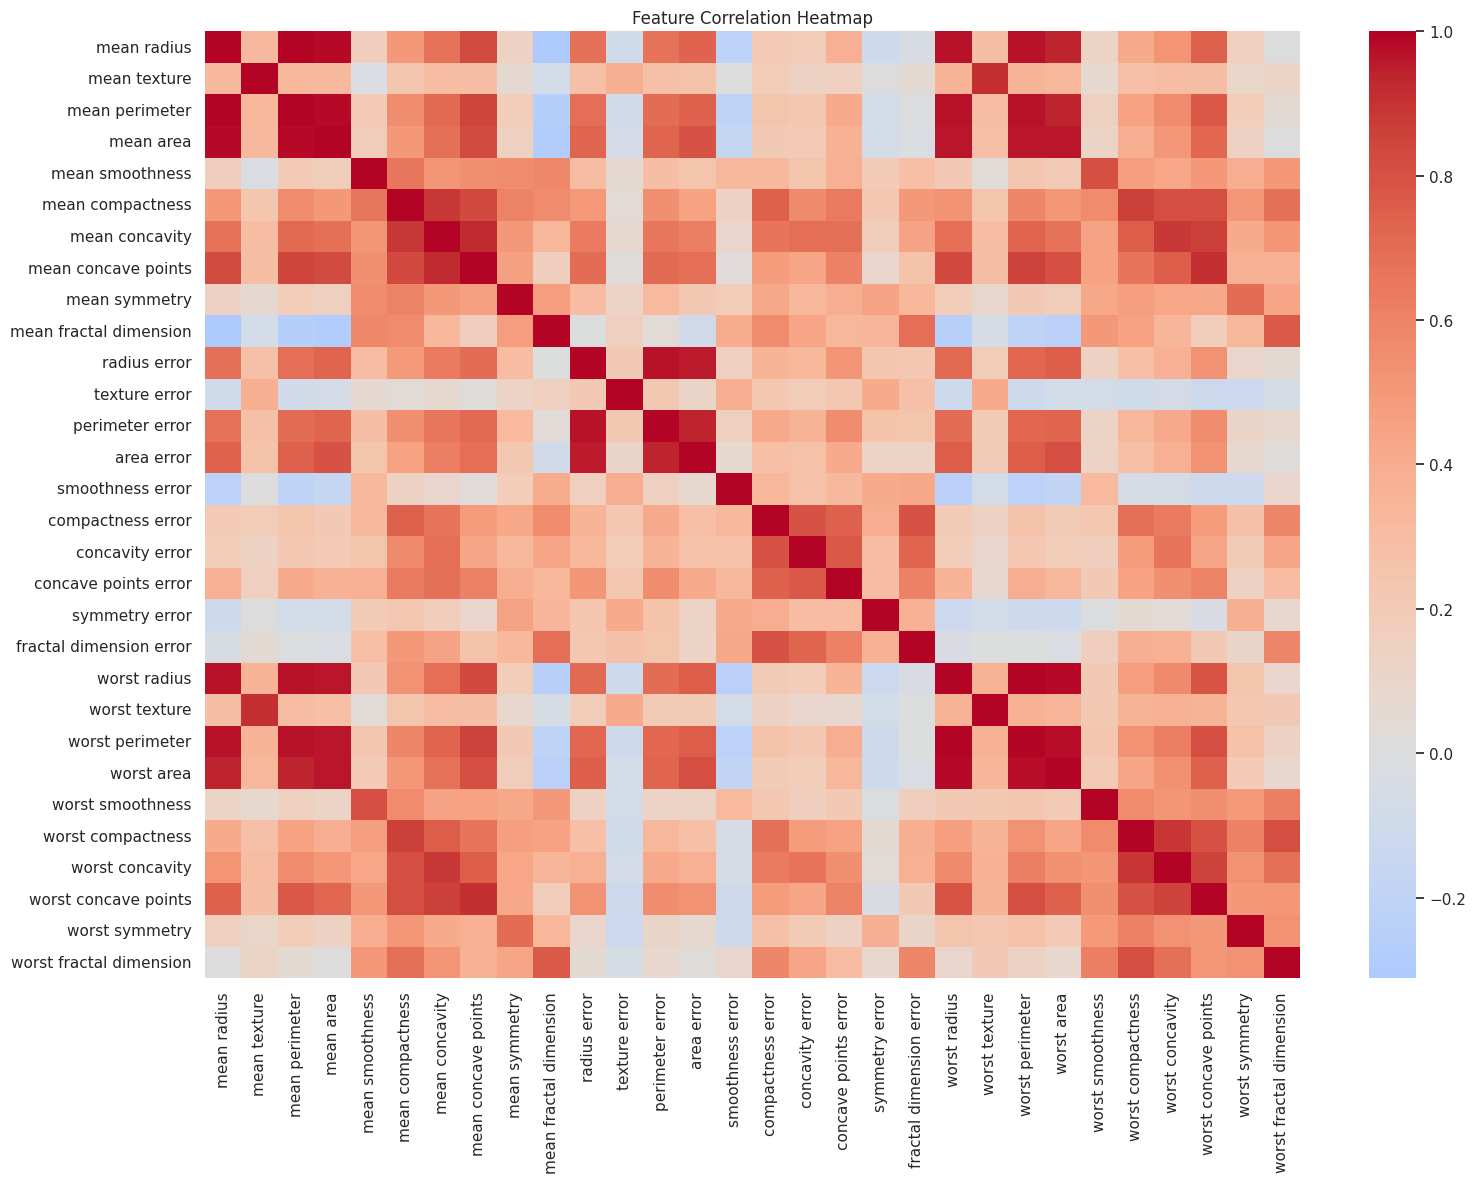

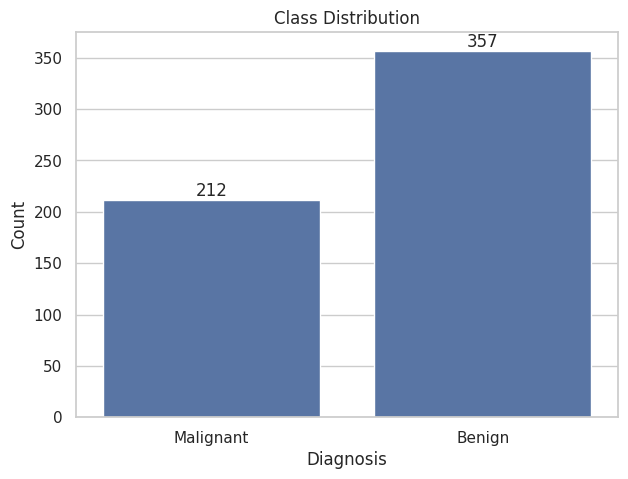

In [4]:
# Histograms for selected key features
key_features = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean smoothness", "mean compactness"
]

df[key_features].hist(figsize=(14, 8), bins=25)
plt.suptitle("Histograms of Key Features")
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[key_features])
plt.xticks(rotation=30, ha="right")
plt.title("Boxplots of Key Features")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Class distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(x=df["Outcome"].map({0: "Malignant", 1: "Benign"}))
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [5]:
class_counts = df["Outcome"].value_counts().sort_index()
class_percent = df["Outcome"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Class": ["Malignant", "Benign"],
    "Count": [class_counts.get(0, 0), class_counts.get(1, 0)],
    "Percentage": [class_percent.get(0, 0), class_percent.get(1, 0)]
})

display(class_summary)

print(
    "The classes are not perfectly balanced. Benign cases are more common than malignant cases. "
    "The imbalance is moderate rather than extreme, but accuracy alone may hide errors in the "
    "less frequent malignant class. Stratified splitting and precision/recall/F1 are therefore important."
)


,Class,Count,Percentage
0,Malignant,212,37.258348
1,Benign,357,62.741652


The classes are not perfectly balanced. Benign cases are more common than malignant cases. The imbalance is moderate rather than extreme, but accuracy alone may hide errors in the less frequent malignant class. Stratified splitting and precision/recall/F1 are therefore important.


*Task 2: Data Preprocessing*

In [6]:
# Target is already binary: 0 = malignant, 1 = benign.
# We keep this clinically meaningful mapping explicit.
y_binary = df["Outcome"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

# Standardization is fitted only on the training data to avoid data leakage.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled training mean (first 5 features):")
print(X_train_scaled[:, :5].mean(axis=0).round(4))

print("Scaled training std (first 5 features):")
print(X_train_scaled[:, :5].std(axis=0).round(4))


Training shape: (455, 30)
Testing shape : (114, 30)

Training class proportions:
Outcome
0    0.373626
1    0.626374
Name: proportion, dtype: float64

Testing class proportions:
Outcome
0    0.368421
1    0.631579
Name: proportion, dtype: float64

Scaled training mean (first 5 features):
[-0.  0. -0.  0.  0.]
Scaled training std (first 5 features):
[1. 1. 1. 1. 1.]


*Task 3 – Model Training and Basic Evaluation*

In [7]:
model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)
recall = recall_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)

metrics_table = pd.DataFrame({
    "Class": ["Malignant (0)", "Benign (1)"],
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

print(f"Accuracy: {accuracy:.4f}")
display(metrics_table)

print("\nComplete classification report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Malignant", "Benign"],
    digits=4
))


Accuracy: 0.9825


,Class,Precision,Recall,F1-score
0,Malignant (0),0.976190,0.976190,0.976190
1,Benign (1),0.986111,0.986111,0.986111



Complete classification report:
              precision    recall  f1-score   support

   Malignant     0.9762    0.9762    0.9762        42
      Benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



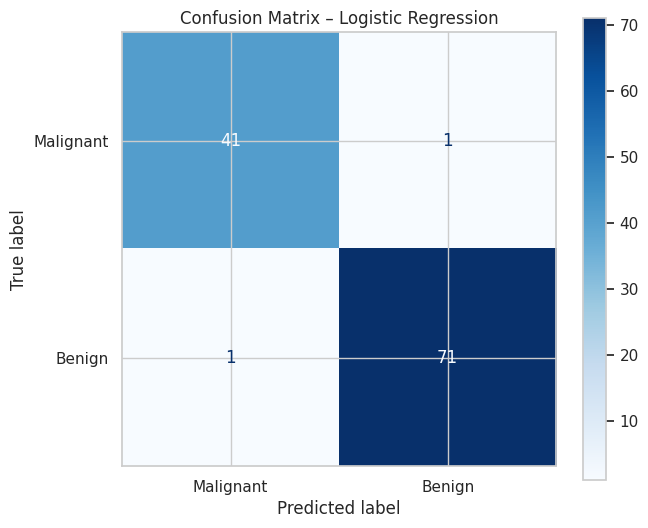

Confusion matrix:
[[41  1]
 [ 1 71]]


In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

print("Confusion matrix:")
print(cm)


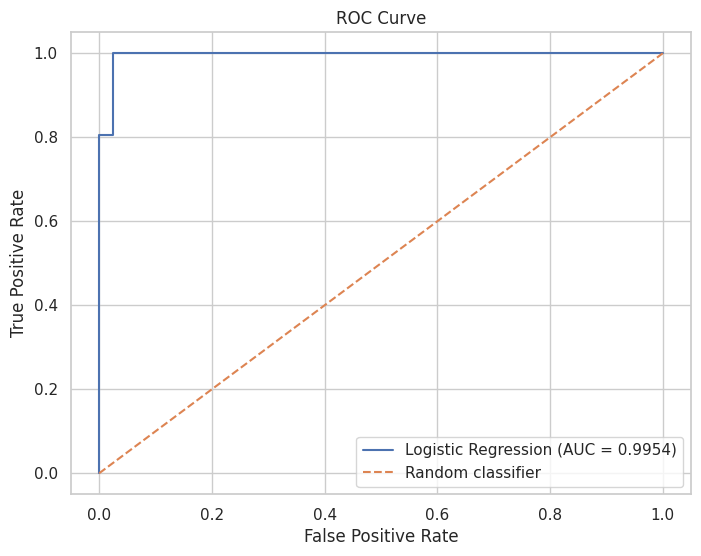

ROC-AUC: 0.9954


In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


*Model Interpretation*

Logistic regression coefficients

In [11]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute_Coefficient", ascending=False)

print("Features with the largest absolute coefficients:")
display(coef_df.head(15))


Features with the largest absolute coefficients:


,Feature,Coefficient,Absolute_Coefficient
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


Regularization

In [12]:
regularized_results = []

for penalty in ["l1", "l2"]:
    reg_model = LogisticRegression(
        penalty=penalty,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )
    reg_model.fit(X_train_scaled, y_train)

    pred = reg_model.predict(X_test_scaled)
    prob = reg_model.predict_proba(X_test_scaled)[:, 1]

    regularized_results.append({
        "Regularization": penalty.upper(),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (Malignant)": precision_score(y_test, pred, pos_label=0, zero_division=0),
        "Recall (Malignant)": recall_score(y_test, pred, pos_label=0, zero_division=0),
        "F1 (Malignant)": f1_score(y_test, pred, pos_label=0, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "Non-zero coefficients": int(np.count_nonzero(reg_model.coef_))
    })

reg_results = pd.DataFrame(regularized_results)
display(reg_results)


,Regularization,Accuracy,Precision (Malignant),Recall (Malignant),F1 (Malignant),ROC-AUC,Non-zero coefficients
0,L1,0.991228,1.00000,0.97619,0.987952,0.996693,16
1,L2,0.982456,0.97619,0.97619,0.976190,0.995701,30


**Medical Interpretation**

For a medical diagnosis problem, a false negative means a malignant case is predicted as benign. This can be more concerning than a false positive because a missed malignant case may delay further investigation or treatment. Therefore, malignant-class recall/sensitivity should be examined alongside precision, F1-score, the confusion matrix, and ROC-AUC rather than relying on accuracy alone.

In [13]:
malignant_recall = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
malignant_precision = precision_score(y_test, y_pred, pos_label=0, zero_division=0)

print(f"Accuracy              : {accuracy:.4f}")
print(f"Malignant precision   : {malignant_precision:.4f}")
print(f"Malignant recall      : {malignant_recall:.4f}")
print(f"Malignant F1-score    : {f1_score(y_test, y_pred, pos_label=0, zero_division=0):.4f}")
print(f"ROC-AUC               : {auc_score:.4f}")

print("\nConfusion matrix interpretation:")
print("Rows = actual classes; columns = predicted classes.")
print("A malignant case in the Benign prediction column is a false negative.")


Accuracy              : 0.9825
Malignant precision   : 0.9762
Malignant recall      : 0.9762
Malignant F1-score    : 0.9762
ROC-AUC               : 0.9954

Confusion matrix interpretation:
Rows = actual classes; columns = predicted classes.
A malignant case in the Benign prediction column is a false negative.


**Conclusion**

Logistic regression was successfully applied to the Breast Cancer Wisconsin (Diagnostic) dataset. The data was explored for summary statistics, missing values, duplicates, outliers, correlations, and class distribution. The target was represented as a binary variable, the dataset was split using stratified sampling, and features were standardized before model training.
The model was evaluated using accuracy, class-wise precision, recall, F1-score, a confusion matrix, ROC curve, and ROC-AUC. Regularized L1 and L2 logistic regression models were also compared, and model coefficients were inspected for interpretation. In a healthcare setting, the results should be interpreted with particular attention to malignant-case recall because false-negative predictions can have serious clinical consequences.